# Phân Cụm Điểm Lớp K58KTP
Sử dụng thuật toán **K-Means** để phân nhóm sinh viên thành 3 cụm dựa trên điểm trung bình tích lũy.

**3 nhóm:**
- 🟢 **Nhóm Giỏi** — Điểm cao
- 🟡 **Nhóm Khá** — Điểm trung bình
- 🔴 **Nhóm Trung Bình / Yếu** — Điểm thấp

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print('✅ Import thành công!')

✅ Import thành công!


## 2. Đọc và xử lý dữ liệu

In [2]:
# Đọc file Excel
FILE_PATH = 'tonghopdiemlop.xlsx'

df_raw = pd.read_excel(FILE_PATH, header=None)

# Trích xuất thông tin sinh viên và điểm
student_ids   = df_raw.iloc[1, 3:].tolist()
student_names = df_raw.iloc[2, 3:].tolist()
subject_names = df_raw.iloc[4:, 2].tolist()
grades_matrix = df_raw.iloc[4:, 3:].copy()

# Chuyển sang số, lỗi → NaN
grades_numeric = grades_matrix.apply(pd.to_numeric, errors='coerce')

# Tính điểm trung bình từng sinh viên
avg_grades = grades_numeric.mean(axis=0)

# Tạo DataFrame sinh viên
students = pd.DataFrame({
    'MSSV'   : student_ids,
    'Ho_Ten' : student_names,
    'DTB'    : avg_grades.values
})

# Lọc sinh viên hợp lệ (có MSSV bắt đầu bằng K, có điểm)
students = students[students['MSSV'].astype(str).str.startswith('K')]
students = students.dropna(subset=['DTB'])
students['DTB'] = students['DTB'].round(2)
students = students.reset_index(drop=True)

print(f'📊 Tổng số sinh viên hợp lệ: {len(students)}')
print(f'📚 Tổng số môn học: {len(subject_names)}')
print(f'\n📈 Thống kê điểm trung bình:')
print(students['DTB'].describe().round(3))

📊 Tổng số sinh viên hợp lệ: 60
📚 Tổng số môn học: 52

📈 Thống kê điểm trung bình:
count    60.000
mean      2.705
std       0.378
min       1.920
25%       2.425
50%       2.655
75%       2.992
max       3.550
Name: DTB, dtype: float64


## 3. Kiểm tra phân phối điểm

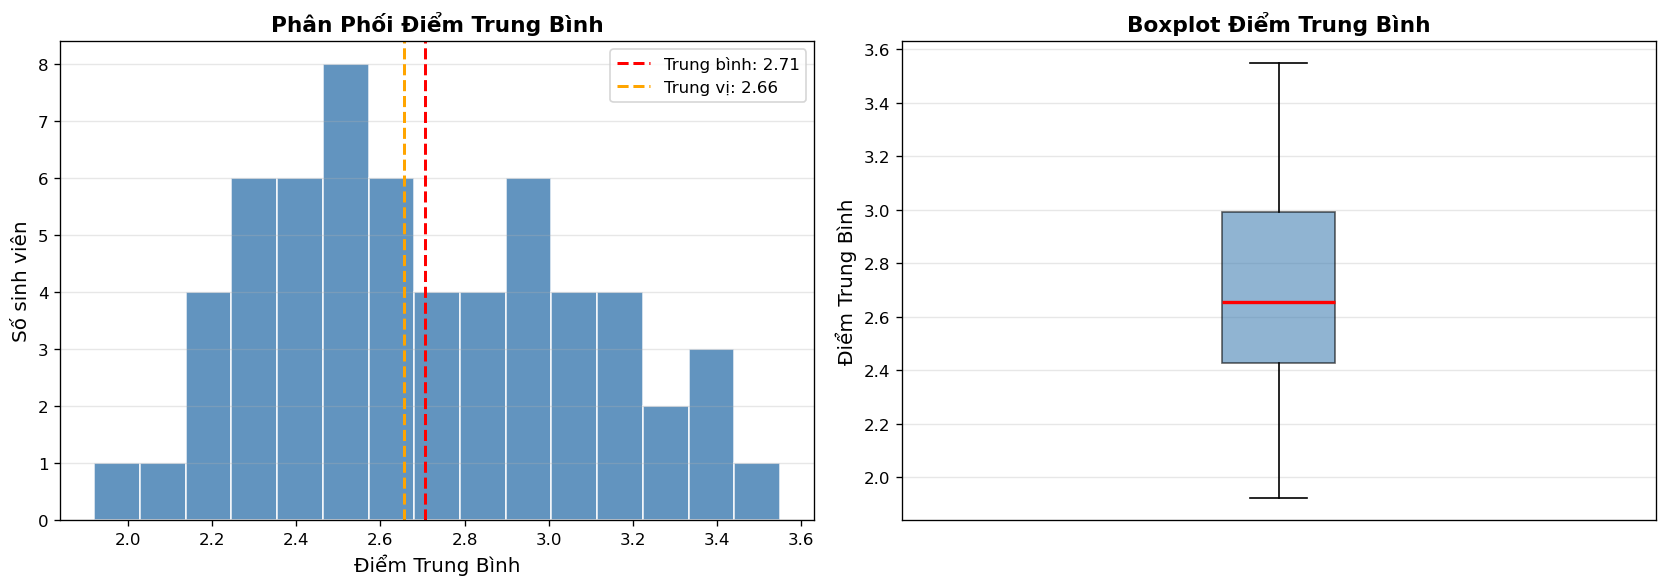

📊 Biểu đồ phân phối điểm đã hiển thị.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(students['DTB'], bins=15, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(students['DTB'].mean(), color='red', linestyle='--', linewidth=1.8, label=f"Trung bình: {students['DTB'].mean():.2f}")
axes[0].axvline(students['DTB'].median(), color='orange', linestyle='--', linewidth=1.8, label=f"Trung vị: {students['DTB'].median():.2f}")
axes[0].set_xlabel('Điểm Trung Bình', fontsize=12)
axes[0].set_ylabel('Số sinh viên', fontsize=12)
axes[0].set_title('Phân Phối Điểm Trung Bình', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
axes[1].boxplot(students['DTB'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Điểm Trung Bình', fontsize=12)
axes[1].set_title('Boxplot Điểm Trung Bình', fontsize=13, fontweight='bold')
axes[1].set_xticks([])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('phan_phoi_diem.png', bbox_inches='tight')
plt.show()
print('📊 Biểu đồ phân phối điểm đã hiển thị.')

## 4. Xác định số cụm tối ưu (Elbow Method)

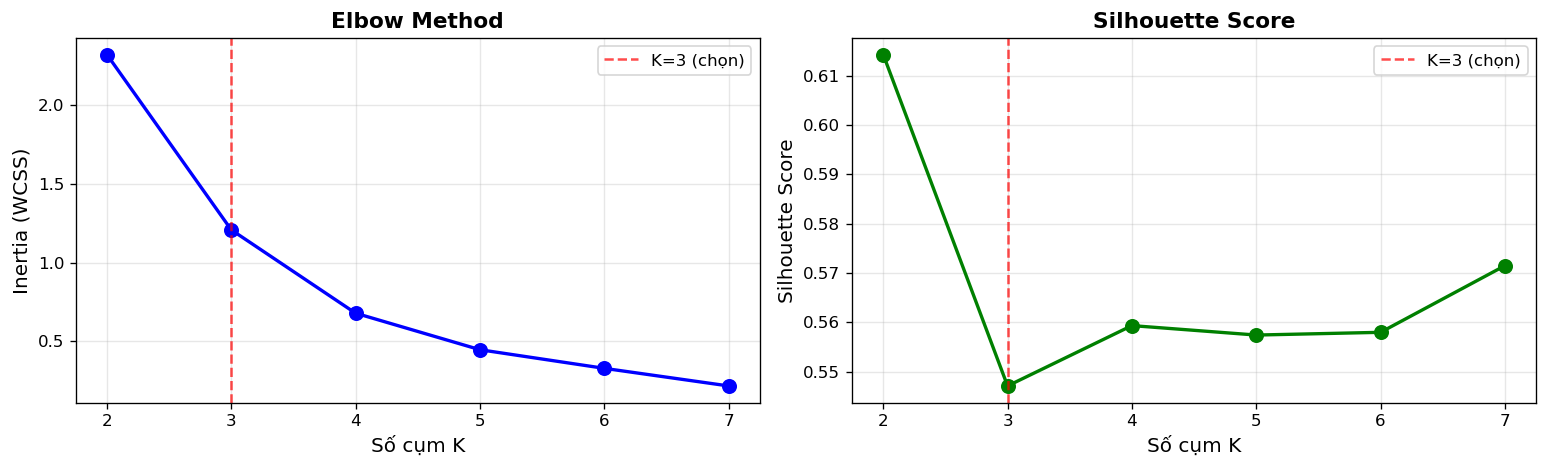


📌 Silhouette Score với K=3: 0.5471


In [4]:
X = students[['DTB']].values

inertia_list = []
sil_list     = []
K_range      = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia_list.append(km.inertia_)
    sil_list.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(3, color='red', linestyle='--', alpha=0.7, label='K=3 (chọn)')
axes[0].set_xlabel('Số cụm K', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), sil_list, 'go-', linewidth=2, markersize=8)
axes[1].axvline(3, color='red', linestyle='--', alpha=0.7, label='K=3 (chọn)')
axes[1].set_xlabel('Số cụm K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()
print(f'\n📌 Silhouette Score với K=3: {sil_list[1]:.4f}')

## 5. Áp dụng K-Means với K=3

In [5]:
# Phân loại theo ngưỡng điểm cố định
def xep_loai(dtb):
    if dtb >= 3.2:
        return 'Giỏi'
    elif dtb >= 2.5:
        return 'Khá'
    else:
        return 'Trung Bình / Yếu'

students['Nhom'] = students['DTB'].apply(xep_loai)

color_map = {
    'Giỏi'            : '#27AE60',
    'Khá'             : '#F39C12',
    'Trung Bình / Yếu': '#E74C3C'
}

print('✅ Phân loại hoàn tất!\n')
print('📊 Thống kê từng nhóm:')
summary = students.groupby('Nhom')['DTB'].agg(['count','min','mean','max']).round(2)
summary.columns = ['Số SV', 'Điểm Thấp Nhất', 'Điểm TB', 'Điểm Cao Nhất']
summary.index.name = 'Nhóm'
print(summary.to_string())

✅ Phân loại hoàn tất!

📊 Thống kê từng nhóm:
                  Số SV  Điểm Thấp Nhất  Điểm TB  Điểm Cao Nhất
Nhóm                                                           
Giỏi                  7            3.21     3.34           3.55
Khá                  34            2.50     2.81           3.18
Trung Bình / Yếu     19            1.92     2.29           2.48


## 6. Trực quan hoá kết quả phân cụm

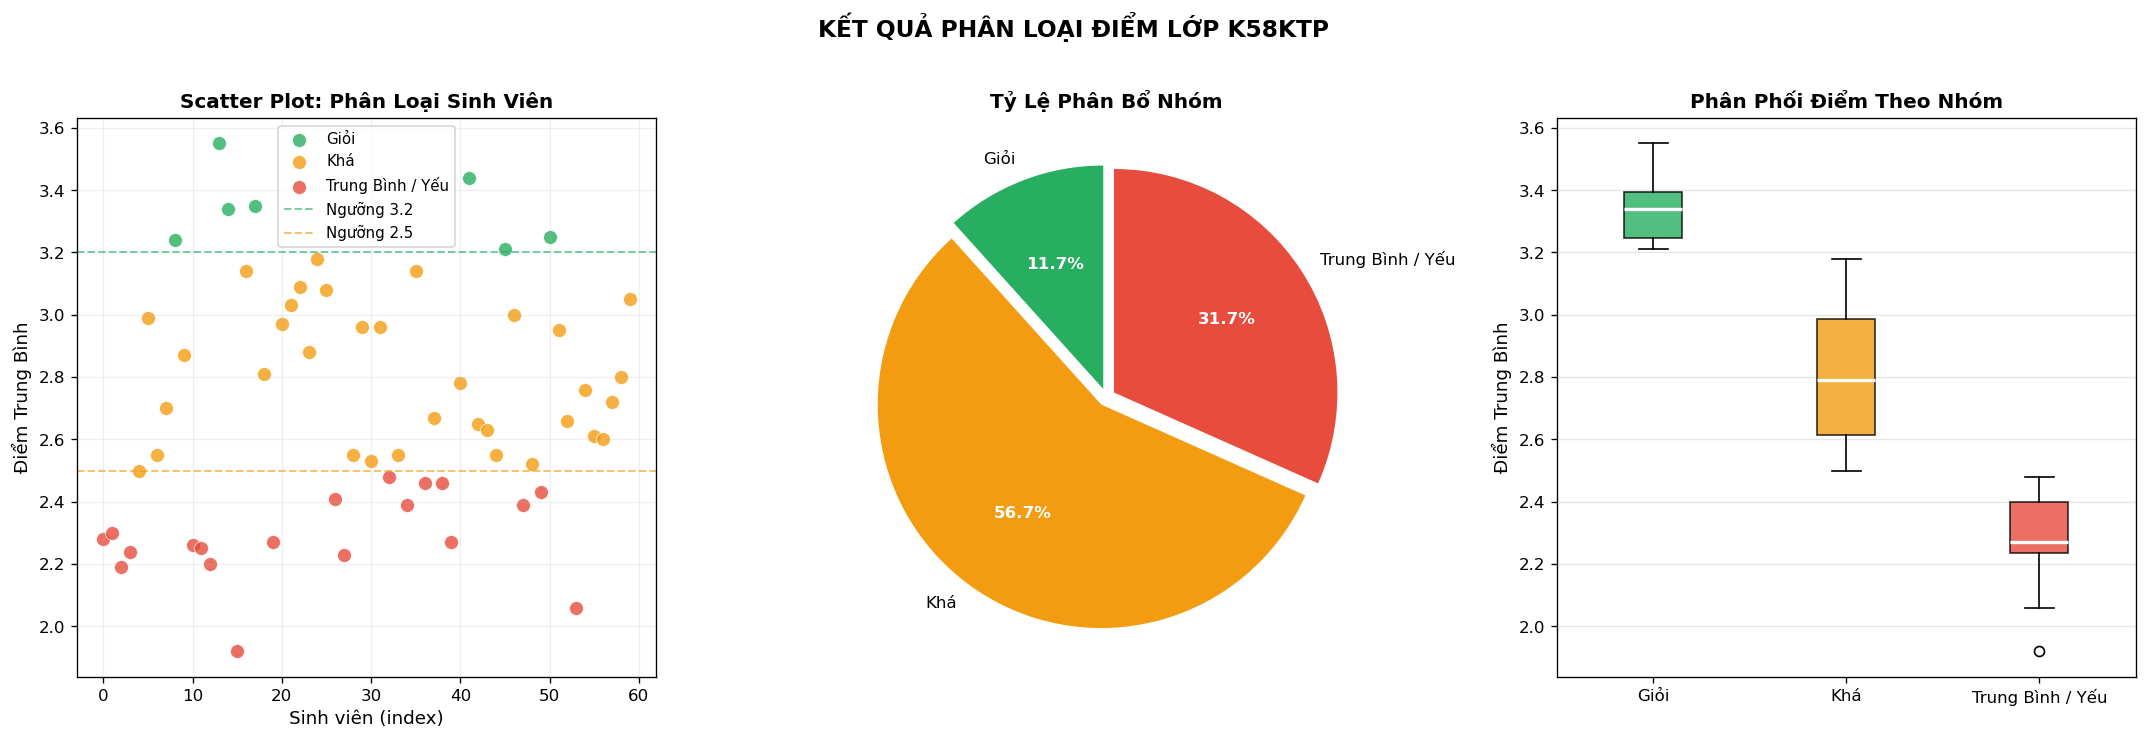

📊 Biểu đồ kết quả đã lưu: ket_qua_phan_cum.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

color_map_nhom = {
    'Giỏi'            : '#27AE60',
    'Khá'             : '#F39C12',
    'Trung Bình / Yếu': '#E74C3C'
}

# --- Scatter plot ---
ax = axes[0]
for nhom in ['Giỏi', 'Khá', 'Trung Bình / Yếu']:
    mask = students['Nhom'] == nhom
    ax.scatter(
        students[mask].index,
        students[mask]['DTB'],
        c=color_map_nhom[nhom], label=nhom, alpha=0.8, s=70, edgecolors='white', linewidth=0.5
    )
# Vẽ đường ngưỡng
ax.axhline(3.2, linestyle='--', color='#27AE60', alpha=0.6, linewidth=1.2, label='Ngưỡng 3.2')
ax.axhline(2.5, linestyle='--', color='#F39C12', alpha=0.6, linewidth=1.2, label='Ngưỡng 2.5')
ax.set_xlabel('Sinh viên (index)', fontsize=11)
ax.set_ylabel('Điểm Trung Bình', fontsize=11)
ax.set_title('Scatter Plot: Phân Loại Sinh Viên', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# --- Pie chart ---
ax2 = axes[1]
counts = students['Nhom'].value_counts()
ordered = ['Giỏi', 'Khá', 'Trung Bình / Yếu']
sizes   = [counts.get(lbl, 0) for lbl in ordered]
colors  = ['#27AE60', '#F39C12', '#E74C3C']
explode = [0.04, 0.04, 0.04]
wedges, texts, autotexts = ax2.pie(
    sizes, labels=ordered, colors=colors, autopct='%1.1f%%',
    startangle=90, explode=explode,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
ax2.set_title('Tỷ Lệ Phân Bổ Nhóm', fontsize=12, fontweight='bold')

# --- Box plot by group ---
ax3 = axes[2]
data_by_group = [students[students['Nhom']==n]['DTB'].values for n in ['Giỏi', 'Khá', 'Trung Bình / Yếu']]
group_labels  = ['Giỏi', 'Khá', 'Trung Bình / Yếu']
bp = ax3.boxplot(data_by_group, patch_artist=True, labels=group_labels,
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], ['#27AE60', '#F39C12', '#E74C3C']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax3.set_ylabel('Điểm Trung Bình', fontsize=11)
ax3.set_title('Phân Phối Điểm Theo Nhóm', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('KẾT QUẢ PHÂN LOẠI ĐIỂM LỚP K58KTP',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ket_qua_phan_cum.png', bbox_inches='tight')
plt.show()
print('📊 Biểu đồ kết quả đã lưu: ket_qua_phan_cum.png')

## 7. Danh sách sinh viên từng nhóm

In [7]:
for nhom, color_code in [('Giỏi', '\033[92m'), ('Khá', '\033[93m'), ('Trung Bình / Yếu', '\033[91m')]:
    group_df = students[students['Nhom'] == nhom][['MSSV', 'Ho_Ten', 'DTB']].sort_values('DTB', ascending=False)
    print(f"{color_code}{'='*55}")
    print(f"  📌 NHÓM {nhom.upper()} — {len(group_df)} sinh viên\033[0m")
    print(f"{color_code}{'='*55}\033[0m")
    print(group_df.to_string(index=False))
    print()

  📌 NHÓM GIỎI — 7 sinh viên
         MSSV            Ho_Ten  DTB
K225480106009   Trần Thị Thu Hà 3.55
K225480106053    Hoàng Kim Ngọc 3.44
K225480106019 Nguyễn Trung Hiếu 3.35
K225480106013    Lường Văn Hạnh 3.34
K225480106058 Nguyễn Tiến Thắng 3.25
K225480106093  Nguyễn Đức Dương 3.24
K225480106056   Hoàng Thị Quyến 3.21

  📌 NHÓM KHÁ — 34 sinh viên
         MSSV                 Ho_Ten  DTB
K225480106099          Đậu Văn Khánh 3.18
K225480106016     Hứa Thị Thanh Hiền 3.14
K225480106045           Dương Thị Ly 3.14
K225480106027    Hầu Thị Thanh Huyền 3.09
K225480106030       Nguyễn Như Khiêm 3.08
K225480106073       Lương Hoàng Việt 3.05
K225480106026     Nguyễn Thị Kim Huệ 3.03
K225480106057        Phạm Mạnh Quỳnh 3.00
K225480106100           Lý Văn Cường 2.99
K225480106025          Lương Văn Học 2.97
K225480106040        Nguyễn Thị Linh 2.96
K225480106039     Nguyễn Nguyệt Linh 2.96
K225480106062         Nguyễn Văn Thứ 2.95
K225480106028           Vũ Bảo Khánh 2.88
K225480106003    

## 8. Xuất kết quả ra file Excel

In [ ]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = openpyxl.Workbook()

# ---- Sheet 1: Tổng hợp ----
ws1 = wb.active
ws1.title = 'Tổng Hợp'

title_font  = Font(name='Arial', size=13, bold=True, color='FFFFFF')
header_font = Font(name='Arial', size=10, bold=True, color='FFFFFF')
cell_font   = Font(name='Arial', size=10)

fill_title   = PatternFill('solid', fgColor='1F4E79')
fill_header  = PatternFill('solid', fgColor='2E75B6')
fill_gioi    = PatternFill('solid', fgColor='C6EFCE')
fill_kha     = PatternFill('solid', fgColor='FFEB9C')
fill_tb      = PatternFill('solid', fgColor='FFC7CE')

thin = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'),  bottom=Side(style='thin')
)
center = Alignment(horizontal='center', vertical='center')

# Title
ws1.merge_cells('A1:E1')
ws1['A1'] = 'PHÂN CỤM ĐIỂM LỚP K58KTP — K-Means (K=3)'
ws1['A1'].font = title_font
ws1['A1'].fill = fill_title
ws1['A1'].alignment = center
ws1.row_dimensions[1].height = 30

# Headers
headers = ['STT', 'MSSV', 'Họ Tên', 'ĐTB', 'Nhóm']
for col, h in enumerate(headers, 1):
    c = ws1.cell(row=2, column=col, value=h)
    c.font = header_font
    c.fill = fill_header
    c.alignment = center
    c.border = thin 

# Data sorted by group then DTB desc
order = {'Giỏi': 0, 'Khá': 1, 'Trung Bình / Yếu': 2}
df_sorted = students.copy()
df_sorted['_order'] = df_sorted['Nhom'].map(order)
df_sorted = df_sorted.sort_values(['_order', 'DTB'], ascending=[True, False]).reset_index(drop=True)

fill_map = {'Giỏi': fill_gioi, 'Khá': fill_kha, 'Trung Bình / Yếu': fill_tb}

for i, row in df_sorted.iterrows():
    r = i + 3
    vals = [i+1, row['MSSV'], row['Ho_Ten'], row['DTB'], row['Nhom']]
    for col, val in enumerate(vals, 1):
        c = ws1.cell(row=r, column=col, value=val)
        c.font = cell_font
        c.fill = fill_map[row['Nhom']]
        c.alignment = Alignment(horizontal='center' if col != 3 else 'left', vertical='center')
        c.border = thin

ws1.column_dimensions['A'].width = 6
ws1.column_dimensions['B'].width = 18
ws1.column_dimensions['C'].width = 26
ws1.column_dimensions['D'].width = 10
ws1.column_dimensions['E'].width = 22

# ---- Sheet 2: Thống kê ----
ws2 = wb.create_sheet('Thống Kê')
ws2.merge_cells('A1:D1')
ws2['A1'] = 'THỐNG KÊ THEO NHÓM'
ws2['A1'].font = title_font
ws2['A1'].fill = fill_title
ws2['A1'].alignment = center
ws2.row_dimensions[1].height = 28

stat_headers = ['Nhóm', 'Số SV', 'ĐTB Nhóm', 'Khoảng Điểm']
for col, h in enumerate(stat_headers, 1):
    c = ws2.cell(row=2, column=col, value=h)
    c.font = header_font
    c.fill = fill_header
    c.alignment = center
    c.border = thin

for i, nhom in enumerate(['Giỏi', 'Khá', 'Trung Bình / Yếu']):
    g = students[students['Nhom'] == nhom]['DTB']
    r = i + 3
    row_vals = [nhom, len(g), round(g.mean(), 2), f"{g.min():.2f} – {g.max():.2f}"]
    for col, val in enumerate(row_vals, 1):
        c = ws2.cell(row=r, column=col, value=val)
        c.font = cell_font
        c.fill = fill_map[nhom]
        c.alignment = center
        c.border = thin

for col_letter, width in zip('ABCD', [24, 10, 12, 18]):
    ws2.column_dimensions[col_letter].width = width

output_file = 'Phan_Cum_Diem_K58KTP.xlsx'
wb.save(output_file)
print(f'✅ Đã xuất file: {output_file}')

# Summary
print('\n📋 Tóm tắt kết quả:')
for nhom in ['Giỏi', 'Khá', 'Trung Bình / Yếu']:
    g = students[students['Nhom'] == nhom]['DTB']
    icon = '🟢' if nhom == 'Giỏi' else '🟡' if nhom == 'Khá' else '🔴'
    print(f"  {icon} {nhom:22s}: {len(g):2d} SV  |  ĐTB: {g.mean():.2f}  |  [{g.min():.2f} – {g.max():.2f}]")

✅ Đã xuất file: Phan_Cum_Diem_K58KTP.xlsx

📋 Tóm tắt kết quả:
  🟢 Giỏi                  :  7 SV  |  ĐTB: 3.34  |  [3.21 – 3.55]
  🟡 Khá                   : 34 SV  |  ĐTB: 2.81  |  [2.50 – 3.18]
  🔴 Trung Bình / Yếu      : 19 SV  |  ĐTB: 2.29  |  [1.92 – 2.48]
